El conjunto de datos "Breast Cancer Wisconsin" es ampliamente utilizado para la investigación y el desarrollo de modelos de clasificación en aprendizaje automático y redes neuronales. A continuación, explico en detalle el conjunto de datos:

* Descripción General del Conjunto de Datos
    Nombre: Breast Cancer Wisconsin (Diagnostic)
    Fuente: UCI Machine Learning Repository
    Número de Muestras: 569
    Número de Características: 30
    Etiquetas de Clase: 2 (benigno y maligno)

* Características del Conjunto de Datos
    Cada muestra en el conjunto de datos representa un tumor de mama y tiene 30 características numéricas, que describen diferentes propiedades de las células tumorales.
    
    Las características están divididas en tres categorías principales: la media, el error estándar y el valor máximo (peor) de las características. Para cada una de estas categorías, se calcularon las siguientes 10 características:
        -Radius (Radio): Promedio de las distancias desde el centro a los puntos del perímetro.
        -Texture (Textura): Desviación estándar de los valores de escala de grises.
        -Perimeter (Perímetro).
        -Area (Área).
        -Smoothness (Suavidad): Variación local en las longitudes del radio.
        -Compactness (Compacidad).
        -Concavity (Concavidad): Severidad de las porciones cóncavas del contorno.
        -Concave points (Puntos cóncavos): Número de porciones cóncavas del contorno.
        -Symmetry (Simetría).
        -Fractal dimension (Dimensión fractal).

    Además, hay una columna de etiqueta que indica si el tumor es benigno o maligno.

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*** CARGAR DATOS ***

In [12]:
breast_cancer = load_breast_cancer()
breast_cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [13]:
#Leemos el dataset
data_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
data_df['diagnosis'] = breast_cancer.target
#data_df.head(5)

#data_df.shape

#data_df.info()

#data_df.isnull().sum()

#data_df[data_df.duplicated()]

data_df['diagnosis'].value_counts()

1    357
0    212
Name: diagnosis, dtype: int64

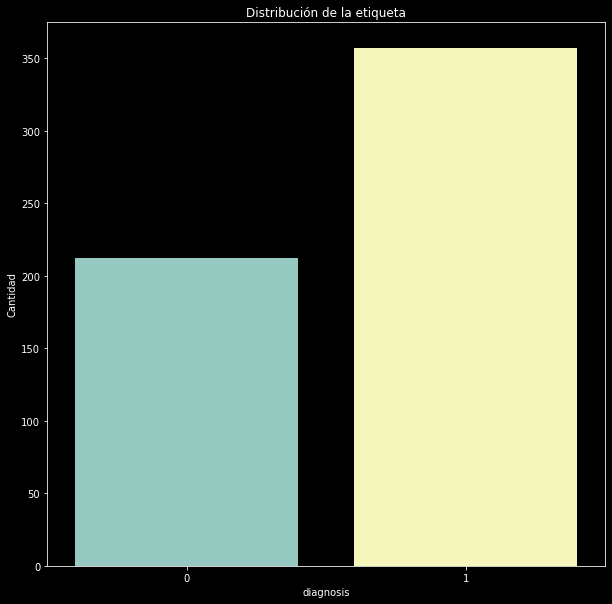

1    62.741652
0    37.258348
Name: diagnosis, dtype: float64

In [14]:
plt.figure(figsize=(10, 10))
sns.countplot(x='diagnosis', data=data_df)
plt.title('Distribución de la etiqueta')
plt.ylabel("Cantidad")
plt.show()

data_df["diagnosis"].value_counts('%') * 100

*** ANÁLISIS EXPLORATORIO DE LOS DATOS ***

In [ ]:
sns.pairplot(data_df, hue='diagnosis')
plt.title('Pair Plot')
plt.show()

Text(0.5, 1.0, 'Mean radius')

<Figure size 1080x1080 with 0 Axes>

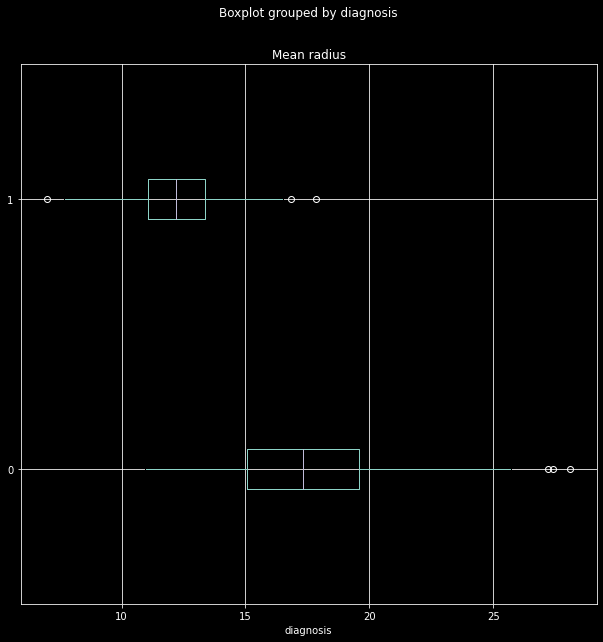

In [15]:
#Crear un diagrama de caja (boxplot) para una características especifica
plt.figure(figsize=(15, 15))
data_df.boxplot(column='mean radius', by='diagnosis', figsize=(10, 10), vert=False)
plt.title('Mean radius')

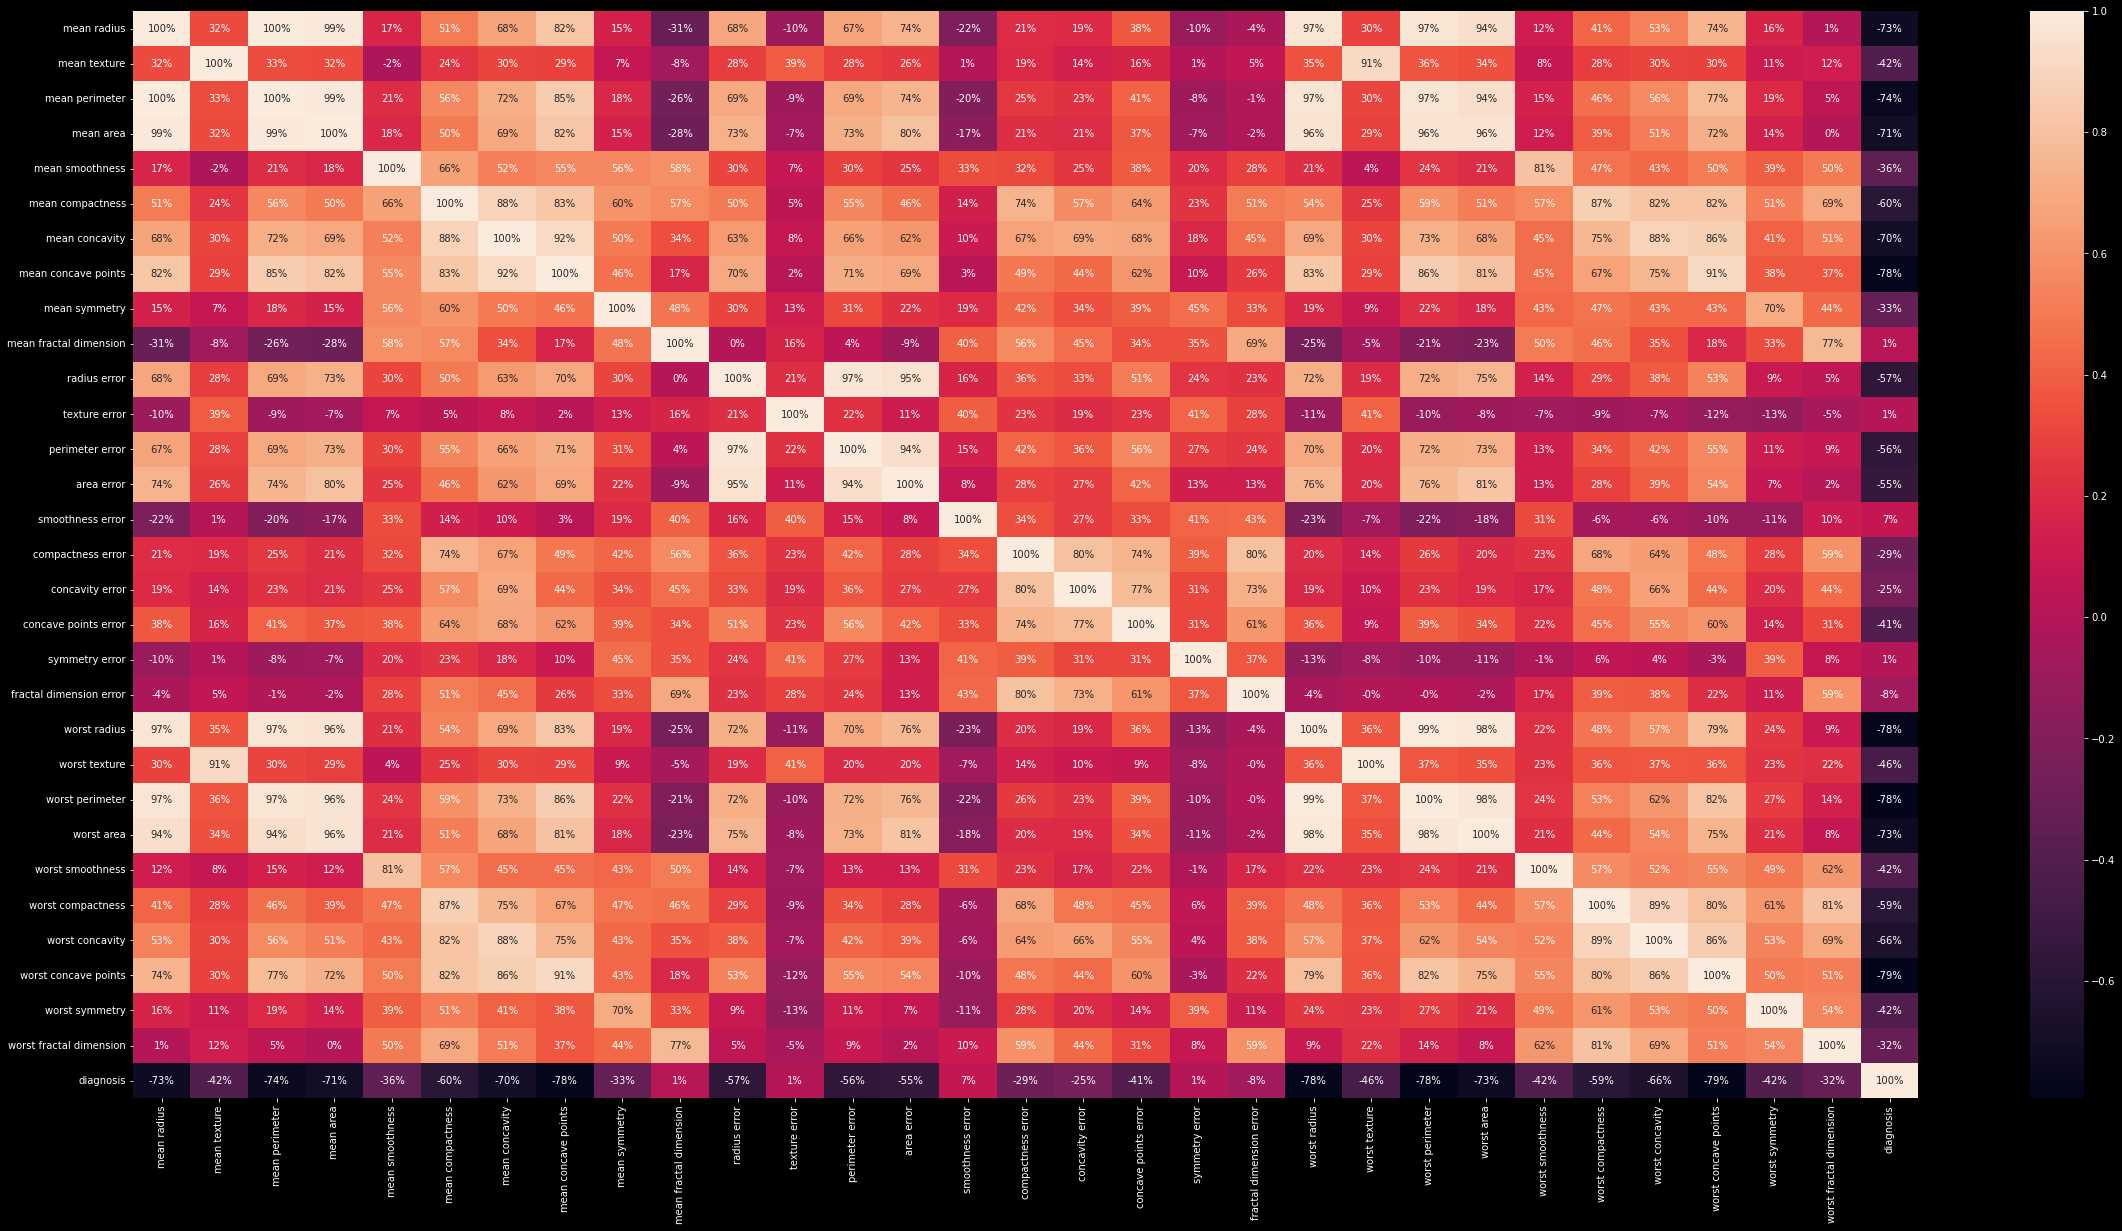

In [16]:
#Correlación
plt.figure(figsize=(10, 10))
sns.heatmap(data_df.corr(), annot=True, fmt='.0%')
plt.gcf().set_size_inches(40, 20)


#Eliminación de columnas
#remove_columns = ["mean area", "mean perimeter"]
#data_df.drop(remove_columns, axis = 1, inplace = True)


*** PREPARACIÓN DE LOS DATOS ***

In [17]:
#Características
X = data_df.drop('diagnosis', axis=1).values
y = data_df['diagnosis'].values

In [18]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

Training cases: 398
Test cases: 171


In [19]:
y_train2 = pd.Series(y_train)
y_test2 = pd.Series(y_test)

print("\nDistribución de clases en y_train:")
print(y_train2.value_counts(normalize=True) * 100)

print("\nDistribución de clases en y_test:")
print(y_test2.value_counts(normalize=True) * 100)


Distribución de clases en y_train:
1    62.81407
0    37.18593
dtype: float64

Distribución de clases en y_test:
1    62.573099
0    37.426901
dtype: float64


In [20]:
#Crear un objeto StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

*** MPLCLASSIFIER - EVALUACIÓN ***

In [21]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, activation='logistic', solver='adam', alpha=0.0001, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(activation='logistic', hidden_layer_sizes=(50,), max_iter=500,
              random_state=42)

In [22]:
#Precedir con los datos del conjunto de prueba
y_pred = mlp.predict(X_test)

print(y_pred)
print(y_test)

[0 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 0 1 0
 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]
[0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 0
 1 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 1 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]


In [23]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y_test, y_pred) * 100
print(f'Exactitud: {accuracy:.2f}%')

Exactitud: 97.66%


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        64
           1       0.99      0.97      0.98       107

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



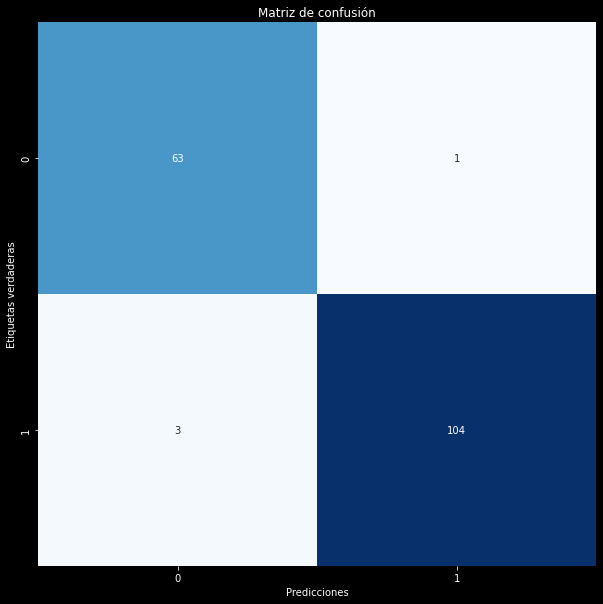

In [25]:
#Creamos el mapa de calor
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de confusión')
plt.show()
            

In [26]:
y_pred_prob = mlp.predict_proba(X_test)[:,1]

#Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)


# Calcular el AUC
auc = roc_auc_score(y_test, y_pred_prob)


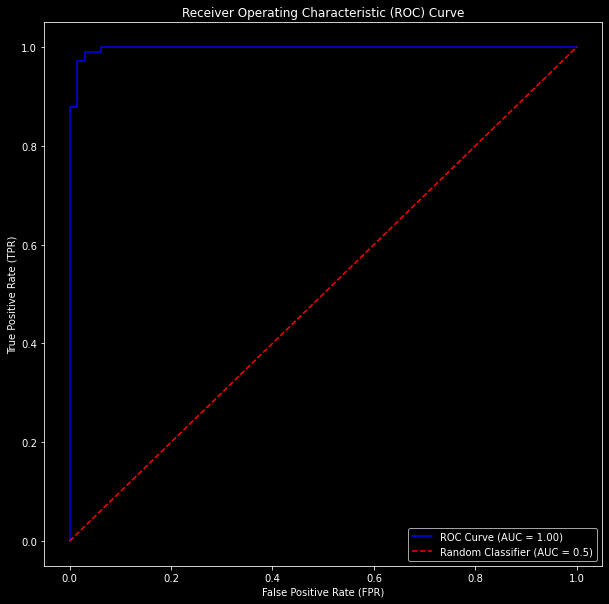

In [27]:
# Visualizar la curva ROC
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


*** PERSISTIR EL MODELO ***

In [28]:
import joblib

#Guardar el modelo entrenado
joblib.dump(mlp, 'tf.joblib')

['tf.joblib']